# 사이킷런으로 시작하는 머신러닝

## 1.사이킷런(머신러닝 라이브러리) 소개와 특징
### 특징: 가장 파이썬스러운 API, 머신러닝을 위한 다양한 알고리즘 개발 위한 편리한 프레임 워크와 API 제공, 실전에서 검증이 되어 있음

In [80]:
import sklearn
print(sklearn.__version__)

1.7.2


## 2.첫 번째 머신러닝 만들어보기-붖꽃 품종 예측하기
### :머신러닝 모델로 분류하는 것: 꽃잎의 길이와 너비, 꽃받힘의 길이와 너비를 기반으로 꽃의 품종 예측
### 지도학습: 명확한 정답이 주어진 데이터를 먼저 학습한 뒤 미지의 정답을 예측하는 것
#### ->학습을 뒤한 다양한 피처와 레이블 데이터(분류 정값)로 모델 학습 후 별도의 데이터 세트에서 미지의 레이블을 예측하는 것
#### ->학습데이터 세트로 학습하고 테스트 데이터 세트로 모델 성능 평가

### 사이킷런의 모든 패키지는 sklearn으로 시작한다.

### 사이킷 런의 다양한 모듈 : 
#### 1.sklearn.datasets내 모듈(사이킷런 자체적 제공 데이터 세트 제공 모듈 모임)
#### 2.sklearn.tree내의 모듈:트리 키반 머신러닝 알고리즘 구현 클래스 모임
#### 3.sklearn.model_selection:학습 데이터와 검증 데이터, 예측 데이터로 데이터 분리하거나 최적의 하이퍼 파라미터로 평가하기 위한 다양한 모듈의 모임
#### ->하이퍼 파라미터:머신러닝 알고리즘 별 최적의 학습을 위해 직접 입력하는 파라미터로 알고리즘의 성능 튜닝이 가능하다

In [81]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier #트리 클래스 중 의사결정 트리를 가져오는 것
from sklearn.model_selection import train_test_split # 데이터 세트를 학습 데이터와 테스트 데이터로 분리하는 함수

In [82]:
import pandas as pd
#붖꽃 데이터 세트 로딩
iris=load_iris()
#iris.data는 iris 데이터 세트에서 피처만으로 된 데이터를 numpy로 가지고 있다.
iris_data=iris.data #피쳐 만으로 된 데이터 넘파이로 가지는 것
#iris.target은 붖꽃 데이터 세이터에서 레이블 데이터를 numpy로 가지고 있다.
iris_label=iris.target
print('iris target값:',iris_label)
print('iris target명:',iris.target_names)
#붖꽃 데이터 세트를 자세히 보기 위해 Data Frame으로 변환
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['label']=iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


#### 피처는 sepal length 등 4개로 이어져 있고 레이블은 세가지 값으로 0,1,2로 각 품종을 의미

### 학습용 데이터와 테스트용 데이터 분리
#### ->반드시 학습용 데이터와 테스트용 데이터의 분리가 필요하다. =>train_test_split() API 제공->test size 파라미터 입력값의 비율로 쉽게 분할 ex) test size가 0.2면 학습데이터 0.8 테스트 데이터 0.2

In [83]:
X_train,X_test,y_train,y_test=train_test_split(iris_data,iris_label,test_size=0.2,random_state=11)

In [84]:
#DecisisonTreeClassifier 객체 생성
df_clf=DecisionTreeClassifier(random_state=11) #random_state=11은 수행할 때마다 동일한 학습/예측 결과 출력 위한 용도

### DecisionTreeClassifier 매서드
### 1.fit()매서드로 학습
### 2.predict(피쳐 데이터)로 테스트

In [85]:
#학습수행
df_clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,11
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
#학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행
pred=df_clf.predict(X_test)

### 예측 결과 기반으로 예측도 평가하는 함수 accuracy_score(실제 레이블 세트, 예측 레이블 데이터 세트)

In [87]:
from sklearn.metrics import accuracy_score
print('예측 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도:0.9333


## 전체 프로세스 정리
### 1.데이터 세트 분리:데이터를 학습 데이터와 테스트 데이터로 분리
### 2.모델 학습: 학습 데이터를 기반으로 ML 알고리즘 적용해 모델 학습
### 3.예측 수행: 학습된 ML 모델을 이용해 테스트 데이터의 분류
### 4.평가: 이렇게 예측 결과와 테스터 데이터의 실제 결과 비교해 ML 모델 성능 평가

## 3.사이킷 런 기반 프래임워크 

### Estimator 이해 및 fit(),predict() 매서드
#### ->fit와 predict 매서드 두 개만으로 쉽게 다양한 알고리즘 구현이 가능하다.
#### 분류 알고리즘 구현 크래스:Classifier 회귀 알고리즘 구현 클래스:Regressor 
#### ->이 두 가지를 합쳐서 Estimator 클래스라고 부름 그리고 이것은 안에서 fit과 predict를 내부적으로 구현한다.

### 사이킷런의 주요 모듈(92~93pg 참고)

### 내장된 예제 데이터 세트(사이킷런에서 제공하는 데이터들 -분류나 회귀해보기 좋음) (94~95참고)


#### data,target은 넘파이, 이름은 파이썬 리스트 타입

In [88]:
from sklearn.datasets import load_iris
iris_data=load_iris()
print(type(iris_data)) #bunch 클래스는 딕셔너리와 유사하다

<class 'sklearn.utils._bunch.Bunch'>


In [89]:
keys=iris_data.keys()
print('붖꽃 데이터 세트의 키들:',keys)

붖꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


#### 데이터 키는 피처들의 데이터 값을 가리킨다.
#### ->자세한 것은 96pg 그림 참고

In [90]:
print('\n feature_names의 type:',type(iris_data.feature_names))
print('\n feature_names의 shape:',len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type:',type(iris_data.target_names))
print('\n target_names의 shape:',len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:',type(iris_data.data))
print('\n data의 shape:',iris_data.data.shape)
print(iris_data['data'])

print('\n target의 type:',type(iris_data.target))
print('\n target의 shape:',iris_data.target.shape)
print(iris_data['target'])


 feature_names의 type: <class 'list'>

 feature_names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type: <class 'numpy.ndarray'>

 target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>

 data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]


## 4.Module Selection 모듈 소개

### 학습/테스트 데이터 세트 분리- train_test_split()

In [91]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris=load_iris()
dt_clf=DecisionTreeClassifier()
train_data=iris.data
train_label=iris.target
dt_clf.fit(train_data,train_label)

#학습데이터로 예측 수행
pred=dt_clf.predict(train_data)
print('예측 정확도:',accuracy_score(train_label,pred))

예측 정확도: 1.0


### 이미 학습 데이터 세트 기반으로 학습했기 때문에 100%이고 따라서 학습 데이터와 데이터 세트를 분리하는 것이 필요하다.

### sklearn.model_selection 모듈에서 train_test_split로드
#### :튜플 형태로 반환하고 각각에 반환한다.
#### 주요 파라미터:test_size,train_size(test_size를 쓰기 때문에 잘 사용되지 않음),shuffle(데이터를 분리하기 전에 미리 섞을지),random_state(동일한 학습/테스트용 데이터 세트 생성 위한 난수값)

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf=DecisionTreeClassifier()
iris_data=load_iris()
X_train,X_test,y_train,y_test=train_test_split(iris_data.data,iris_data.target,test_size=0.3,random_state=121)

In [93]:
dt_clf.fit(X_train,y_train)
pred=dt_clf.predict(X_test)
print("예측 정확도:{0:.4f}".format(accuracy_score(pred,y_test)))

예측 정확도:0.9556


#### ->테스트 데이터의 양이 많은 것도 중요하지만 다양한 데이터 기반 예측 성능 평가해보는 것도 중요하다

## 교차 검증 
#### :본고사를 치기 전에 모의고사 여러 번 보는 것과 같은 것
#### ->별도의 여러 세트로 구성된 학습 데이터 세트와 검증 데이터 세트에서 학습 평가 수행
#### ->>각 세트에서 수행 형가 결과에 따라 하이퍼 파라미터 튜닝도 수월하게 할 수 있음

#### ->예측 성능 평가 위한 별도의 데이터도 필요하지만 과적합(overfitting)에 취약하기에 다른 데이터로 하면 취약할 수 있음 ->test 데이터만 잘 맞추게 될 수 있음
#### ->이를 개선하기 위해 교차 검증을 함

#### 교차 검증에서는 학습데이터와 테스트 데이터 외에도검증 데이터를 사용한다.

## 1. K폴드 교차 검증
### :K개의 데이터 폴드 세트를 만들어 K번 만큼 각 폴드 세트에 학습과  검증 평가를 반복적으로 수행하는 방법
#### ex) K가 5라면 5개의 예측 평가를 구하고 이를 평균해서 K폴드 평가 결과로 반영

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris=load_iris()
features=iris.data
labels=iris.target
dt_clf=DecisionTreeClassifier(random_state=156)

#5개의 폴드 세트로 분리한 KFold 객체와 폴드 세트별 정확도를 담은 리스트 객체 생성
kfold=KFold(n_splits=5)
cv_accuracy=[]
print('붖꽃 데이터 세트 크기:',features.shape[0])


붖꽃 데이터 세트 크기: 150


In [95]:
n_iter=0
#KFold 객체의 split()를 호출하면 폴드별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환
for train_index,test_index in kfold.split(features):
    #kfold.split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    X_train,X_test=features[train_index],features[test_index]
    y_train,y_test=labels[train_index],labels[test_index]
    #학습 및 예측
    dt_clf.fit(X_train,y_train)
    pred=dt_clf.predict(X_test)
    n_iter+=1
    #반복시마다 정확도 측정
    accuracy=np.round(accuracy_score(y_test,pred),4) #반올림 함수
    train_size=X_train.shape[0]
    test_size=y_train.shape[0]
    print('\n#{0} 교차 검증 정확도:{1}, 학습 데이터의 크기:{2}, 검증 데이터의 크기:{3}'.format(n_iter,accuracy,train_size,test_size))
    print('#{0} 검증 데이터 세트 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
#개별 iteration 별 정확도를 합하여 평균 정확도 계산
print('\n## 평균 검증 정확도:',np.mean(cv_accuracy))







#1 교차 검증 정확도:1.0, 학습 데이터의 크기:120, 검증 데이터의 크기:120
#1 검증 데이터 세트 인덱스:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도:0.9667, 학습 데이터의 크기:120, 검증 데이터의 크기:120
#2 검증 데이터 세트 인덱스:[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도:0.8667, 학습 데이터의 크기:120, 검증 데이터의 크기:120
#3 검증 데이터 세트 인덱스:[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도:0.9333, 학습 데이터의 크기:120, 검증 데이터의 크기:120
#4 검증 데이터 세트 인덱스:[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도:0.7333, 학습 데이터의 크기:120, 검증 데이터의 크기:120
#5 검증 데이터 세트 인덱스:[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.9


## 2. Startified K 폴드 
### :불균형한 분포도를 가진 레이블 데이터 집합(특정 레이블 값이 특이하게 많거나 적어 분포가 한쪽으로 치우치는 것)을 위한 K폴드 방식
#### ex)대출 사기 데이터 예측시 레이블은(대출 사기:1, 정상 대출:0)으로 구성 전체 1억건 중 대출 사기가 1000건이라면 비율이 매우 적기 때문에 랜덤하게 해도 잘 반영못할 수도 있음
#### ->비율은 적지만 대출 사기 값이 1은 예측에 중요하기 때문에 원본 데이터와 유사한 대출 사기 레이블 값의 분포를 학습 / 테스트 데이터 세트에 유지시키는 것이 중요함
#### ->왜곡된 레이블 데이터 세트에서는 이 방식을 사용한다.
#### ->회귀 결정값 이산값 형태가 아니기 때문에 연속된 숫자값이기 때문이다.


In [96]:
import pandas as pd
iris=load_iris()
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

#### 기존 K 붖꽃 데이터의 경우 레이블 분포가 동일하다

In [97]:
kfold=KFold(n_splits=3)
n_iter=0
for train_index, test_index in kfold.split(iris_df):
    n_iter+=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print("##교차 검증: {0}".format(n_iter))
    print('학습레이블 데이터 분포:\n',label_train.value_counts())
    print('학습레이블 데이터 분포:\n',label_test.value_counts())

##교차 검증: 1
학습레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
##교차 검증: 2
학습레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
##교차 검증: 3
학습레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


## StratifiedKFold는 피처데이터 세트 뿐만 아니라 레이블 데이터 세트도 필요한데 레이블 데이터 분포도에 따라 하기 때문

In [98]:
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=3)
n_iter=0
for train_index, test_index in skf.split(iris_df,iris_df['label']):
    n_iter=1
    label_train=iris_df['label'].iloc[train_index]
    label_test=iris_df['label'].iloc[test_index]
    print('## 교차 검증 {0}'.format(n_iter))
    print('학습레이블 데이터 분포:\n',label_train.value_counts())
    print('학습레이블 데이터 분포:\n',label_test.value_counts())

## 교차 검증 1
학습레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
## 교차 검증 1
학습레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
## 교차 검증 1
학습레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
학습레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [99]:
dt_clf=DecisionTreeClassifier(random_state=156)
skfold=StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

#StratifiedKfold의 split() 출 시 반드시 레이블 데이터 세트도 추가 입력 필요
for train_index,test_index in skfold.split(features,labels):
    #split()로 반환된 인덱스를 이용해 학습용 검증용 테스트 데이터 추출
    X_train, X_test=features[train_index],features[test_index]
    y_train,y_test=labels[train_index],labels[test_index]
    #학습 및 예측
    dt_clf.fit(X_train,y_train)
    pred=dt_clf.predict(X_test)
    #반복 시마다 정확도 측정
    n_iter+=1
    accuracy=np.round(accuracy_score(y_test,pred),4)
    train_size=X_train.shape[0]
    test_size=X_test.shape[0]
    print('\n#{0} 교차 검증 정확도: {1},학습 데이터 크기:{2},검증 데이터 크기:{3}'.format(n_iter,accuracy,train_size,test_size))
    print('#{0} 검증 데이터 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    #교차 검증별정확도 및 평균 정확도 계산
print('\n## 교차 검증별 정확도:',np.round(cv_accuracy,4))
print('##평균 검증 정확도:',np.round(np.mean(cv_accuracy),4))
    


#1 교차 검증 정확도: 0.98,학습 데이터 크기:100,검증 데이터 크기:50
#1 검증 데이터 인덱스:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도: 0.94,학습 데이터 크기:100,검증 데이터 크기:50
#2 검증 데이터 인덱스:[ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도: 0.98,학습 데이터 크기:100,검증 데이터 크기:50
#3 검증 데이터 인덱스:[ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
##평균 검증 정확도: 0.9667


### 교차 검증을 보다 간편하게 -cross_val_score()
#### ->앞에서의 귀찮은 과정을 다 해주는 것
#### 주요 파라미터: estimator,x=피처 데이터 세트,y=레이블 데이터 세트,scoring=예측 성능 평가, cv=교차 검증 폴드 수 의미
#### API 내부에서 학습 예측 평까지 다해줌
#### cross_val_score는 내부적으로 StratifiedKFold 이용

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.datasets import load_iris
iris_data=load_iris()
dt_clf=DecisionTreeClassifier(random_state=156)
data=iris_data.data
label=iris_data.target

#성능 지표는 정확도(accuruacy),교차 검증 세트는 3개)
scores=cross_val_score(dt_clf,data,label,scoring='accuracy',cv=3)
print('교차 검증별 정확도:',np.round(scores,4))
print('평균 검증 정확도:',np.round(np.mean(scores),4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


## GridSearchCv -교차 검증과 하이퍼 파라미터 튜닝을 한번에
### :classifier과 regressor와 같은 알고리즘에 사용되는 하이퍼 파라미터를 순차적으로 입력하며 편리하게 최적의 파라미터 도출 방안 제공
#### ->grid는 격자라는 뜻으로 촘촘하게 파라미터 입력하면서 테스트 하는 방식
### 주요 파라미터:estimator,param_grid-딕셔너리 주어짐,scoring,cv,refit-최적의 하이퍼 파라미터 찾고 학습시킴

In [101]:
grid_parameters={'max_depth':[1,2,3],'min_samples_split':[2,3]}

#### ->총 6회에 걸쳐 파라미터를 순차적으로 바꿔 실행하면서 최적의 파라미터와 수행 결과 도출
#### ->하이퍼 파라미터 최적값을 찾을 수 있음
#### ->cross-validation을 위한 학습/테스트 세트로 자동 분활한 이후 하이퍼 파라미터 그리드에 기술된 모든 파라미터 순차적 적용해 최적의 파라미터 찾을 수 있다
#### ->cv=3 이면 개별 파라미터마다 3회 걸쳐 실시

In [102]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
#데이터를 로딩하고 학습 데이터와 테스트 분리
iris_data=load_iris()
X_train,X_test,y_train,y_test=train_test_split(iris_data.data,iris_data.target,test_size=0.2,random_state=121)
dtree=DecisionTreeClassifier()

#파라미터를 딕셔너리 형태로 설정
parameters={'max_depth':[1,2,3],'min_samples_split':[2,3]}

In [103]:
import pandas as pd
#param_grid의 하이퍼 파라미터 3개를 train,test set fold로 나누어 테스트 수행 설정
###refir=True가 default임 True면 가장 좋은 파라미터 설정을 재학습 시킴
grid_dtree=GridSearchCV(dtree,param_grid=parameters,cv=3,refit=True)

#붓꽃 학습 데이터로 param_gird의 하이퍼 파라미터를 순차적으로 학습/평가
grid_dtree.fit(X_train,y_train)

#GridSearchCV 결과를 추출해 DataFrame으로 변환
scores_df=pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params','mean_test_score','rank_test_score','split0_test_score','split1_test_score','split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [104]:
print('GridSearchCV 최적 파라미터:',grid_dtree.best_params_)
print('GridSearchCV 최적 정확도:{0:4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최적 정확도:0.975000


#### ->best_estimator_로 해서 최적 학습 반환

In [105]:
#GridSearchCV의 refit로 이미 학습된 estimator 변환
estimator=grid_dtree.best_estimator_

#GridSearchCV의 best_estimator_는 이미 학습이 왰으므로 별도 학습이 필요 없음
pred=estimator.predict(X_test)
print('테스트 데이터 세트 정확도:{0:.4f}'.format(accuracy_score(y_test,pred)))

테스트 데이터 세트 정확도:0.9667


## 5. 데이터 전처리
### :알고리즘 만큼 어떤 데이터를 입력으로 가지느냐에 따라 결과도 크게 달라짐 그 데이터를 알고리즘에 적용하기 전에 미리 처리하는 것
#### 결손값은 절대 허용X -> 다른 값으로 변환을 해야 한다. 얼마되지 않으면 평균값으로 대체할 수 있는데 평균 피쳐값으로 하면 예측 왜곡이 심할 수 있으니 상세 검토가 필요하다

#### ->사이킷런의 머신러닝 알고리즘을 문자열 값을 입력값으로 허용하지 않는다. ->숫자형으로 바꿔야 한다. ->불필요하면 삭제를 하자

## 데이터 인코딩 (레이블 인코딩, 원-핫 인코딩)
### 1.레이블 인코딩: 카테고리 피처를 코드형 숫자로 변환하는 것
#### ->문자열 값을 숫자값으로 바꾼다
#### ->사이킷런에서는 LabelEncoder 클래스로 구현하고 객체로 생성하고 fit()와 transform()로 호출한다

#### ->그러나 인코딩 값도 크고 작음이있기 때문에 가중치가 반영될 수 있음 트리에서는 상관 없지만 다른 곳에서는 문제를 줌 ->원-핫 인코딩으로 해결 가능

In [106]:
from sklearn.preprocessing import LabelEncoder
items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

#LabelEncoder를 객체로 생성한 후 fit()과 transform()로 레이블 이코딩 수행
encoder=LabelEncoder()
encoder.fit(items)
labels=encoder.transform(items)
print('인코딩 변환값:',labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]


#### 뭐가 어떤 숫자로 인코딩 되었는지 알려면 classes_ 속성으로 확인하면 된다.
#### inverse_transform 인코딩 값 디코딩할 수 있다.

In [107]:
print('인코딩 클래스:',encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [108]:
print('디코딩 원본값:',encoder.inverse_transform([4,5,2,0,1,1,3,3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


## 2.원-핫 인코딩
#### :피처 고유의 값을 열 형태로 차원 변환 후 고유 값 해당하는 칼럼에만 1을 표시하고 나머지에는 0으로 변환하는 것
#### ex)0~5부터 6개 상품 분류 고유 값에 따라 상품 분류 피처를 6개의 상품 분류 고유 값 피처로 변환
### OneHotEncoder로 이용해 변환 뒤 Sparse Matrix 형태이므로 toarray() 매서드로 밀집 행렬(Dense Matrix)로 변환을 해야 한다

In [109]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']
#2차원 ndarray로 변환
items=np.array(items).reshape(-1,1)

#원-핫 인코딩 적용
oh_encoder=OneHotEncoder()
oh_encoder.fit(items)
oh_labels=oh_encoder.transform(items)

#OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환

print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


## 판다스에서는 원-핫 인코딩을 더 쉽게 지원해 주는 것도 있다. - get_dummies() 이용
#### :숫자형으로 문자열 카테고리 굳이 변환 안 해도 바로 변환 가능

In [110]:
import pandas as pd
df=pd.DataFrame({'item':['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


## 피처 스케일링과 정규화
### :서로 다른 변수의 값을 일정한 수준으로 맞추는 작업
### ->대표적 방법 - 1.표준화(standardiztaion) 2.정규화(normalization)

### 1. 표준화: 각각 평균이 0이고 분산이 1인 가우신안 정규 분포를 가진 값으로 변환하는 것
### 2. 정규화: 서로 다른 피처의 크기 동일하기 위한 크기를 변환해주는 개념
### ->사이킷런에서는 정규화를 특이하게 하는데 이를 벡터 정류화라고 한다.

## (1)피처 스케일링(일반적 의미의 표준화와 정규화)
### [StandardScalar]-표준화를 쉽게하기 위한 클래스 :개별피처를 평균이 0이고 분산이 1인 값으로 변환
### ->이렇게 가우시안 정규 분포를 가지게 변환하는 것은 특정 알고리즘 등에서 중요하다


In [111]:
from sklearn.datasets import load_iris
import pandas as pd
#붗꽃 데이터를 DataFrame으로 변환
iris=load_iris()
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
print('features들의 평균 값')
print(iris_df.mean())
print('\nfeatures들의 분산 값')
print(iris_df.var())

features들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

features들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


#### ->StandardScalar로 각 피처 한꺼번에 변환 transform()는 변환된 데이터 세트가 ndarray로 반환된다.

In [112]:
from sklearn.preprocessing import StandardScaler
#StandardScaler 객체 생성
scaler=StandardScaler()
#StandardScaler로 데이터 세트 변환. fit()과 transform() 호출
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

#transform()시 케일 변환된 데이터 세트가 numpy ndarray로 반환되어 이를 DataFrame으로 변환
iris_df_scaled=pd.DataFrame(data=iris_scaled,columns=iris.feature_names)
print('feature들의 평균값')
print(iris_df_scaled.mean())
print('\nfeature들의 분산 값')
print(iris_df_scaled.var())

feature들의 평균값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


### [MinMaxScalar]
### :데이터 값을 0과 1사이로 변환 음 값이 있으면 -1에서 1사이 데이터가 가우시안 분포가 아닐 때 적용해볼 수 있다.

In [113]:
from sklearn.preprocessing import MinMaxScaler
#MinMaxScaler 생성
scaler=MinMaxScaler()
#MinMaxScaler로 데이터 세트 변환 fit()과 transform() 호출
scaler.fit(iris_df)
iris_scaled=scaler.transform(iris_df)

#transform()시 스케일 변환된 데이터 세트가 numpy ndarray로 변환 되어 이를 DataFrame로 변환
iris_df_scaled=pd.DataFrame(data=iris_scaled,columns=iris.feature_names)
print('feature들의 최소값')
print(iris_df_scaled.min())
print('feature들의 최대값')
print(iris_df_scaled.max())

feature들의 최소값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64
feature들의 최대값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


#### ->모든 피처에서 0과 1사이 변환 스케일링 적용을 알 수 있다.

### 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점
#### ->주로 fit(),transform(),fit_transform을 쓰는데 학습 데이터 세트로 fit transform 적용시 테스트 데이터는 fit 안하고 바로 transform
#### why?:다시 fit를 하면 학습 데이터와 테스트 데이터의 스케일링 기준 정보가 달라져 잘못된 예측 만들 수 있음

In [114]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

#학습 데이터는 0부터 10까지 테스트 데이터는 0부터 5까지 값을 지는 데이터 세트로 생성
#Scaler 클래스의 fit(),transform()는 2차원 이상 데이터만 가능하기에 reshape(-1,1)로 차원 변경

train_array=np.arange(0,11).reshape(-1,1)
test_array=np.arange(0,6).reshape(-1,1)

In [115]:
#MinMaxScaler 객체의 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1값으로 변환
scaler=MinMaxScaler()

#fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정
scaler.fit(train_array)

#1/10 scale로 train_array 데이터 변환 원본 10->1
train_scaled=scaler.transform(train_array)

print('원본 train_array 데이터:',np.round(train_array.reshape(-1),2))
print('Scale된 train_array 데이터',np.round(train_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [116]:
#MinMaxScaler에 test array를 fit하게 되면 원본 데이터의 최솟값이 0 최댓값이 5로 설정된다.
scaler.fit(test_array)
test_scaled=scaler.transform(test_array)
print('원본 test_array 데이터:',np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터',np.round(test_scaled.reshape(-1),2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터 [0.  0.2 0.4 0.6 0.8 1. ]


#### 동일한 데이터에 대해 학습 데이터와 테스트 데이터의 결과가 다르면 잘못된 결과가 나온다 따라서 이미 fit이 적용된 scaler 객체를 이용해 transform 해야함

In [117]:
scaler=MinMaxScaler()
scaler.fit(train_array)
train_scaled=scaler.transform(train_array)
print('원본 train_array 데이터:',np.round(train_array.reshape(-1),2))
print('Scale된 train_array 데이터',np.round(train_scaled.reshape(-1),2))

#test_array에 Scale 변환을 할 때는 반드시 fit()호출하지 않고 transform 만으로 변환을 해야함
test_scaled=scaler.transform(test_array)
print('\n원본 test_array 데이터:',np.round(test_array.reshape(-1),2))
print('\nscaled된 test_array 데이터:',np.round(test_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0 1 2 3 4 5]

scaled된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


### fit나 transform시 유의사항 정리
#### 1.가능하다면 전체 데이터의 스케일링 변환을 적용한 뒤 학습과 테스트 데이터로 분리
#### 2. 1.과정이 힘들다면 학습 데이터로 이미 fit된 Scaler 객체로 테스트 데이터 변환

# 6.사이킷런으로 수행하는 타이타닉 생존자 예측

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
titanic_df=pd.read_csv('train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [119]:
print('\n ###학습 데이터 정보 ### \n')
print(titanic_df.info())


 ###학습 데이터 정보 ### 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


### ->사이킷런은 NULL 값을 허용하지 않기 때문에 DataFrame의 fillna()함수 사용

In [120]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print('데이터 세트 NULL 값 개수 ',titanic_df.isnull().sum().sum())

데이터 세트 NULL 값 개수  0


/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1328/1754568378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1328/1754568378.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

In [121]:
print('Sex 값 분포:\n',titanic_df['Sex'].value_counts())
print('Cabin 값 분포:\n',titanic_df['Cabin'].value_counts())
print('Embarked 값 분포:\n',titanic_df['Embarked'].value_counts())

Sex 값 분포:
 Sex
male      577
female    314
Name: count, dtype: int64
Cabin 값 분포:
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64
Embarked 값 분포:
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [122]:
titanic_df['Cabin']=titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [123]:
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

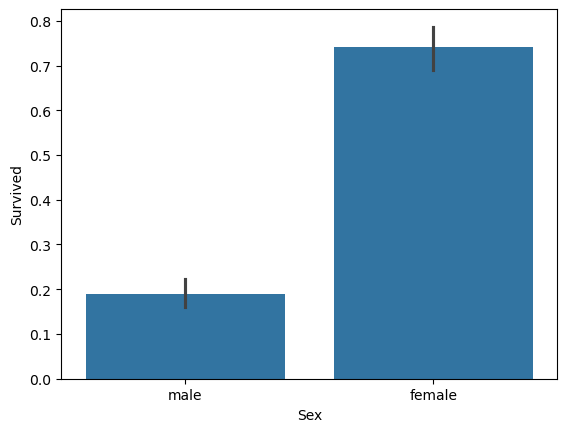

In [124]:
sns.barplot(x='Sex',y='Survived',data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

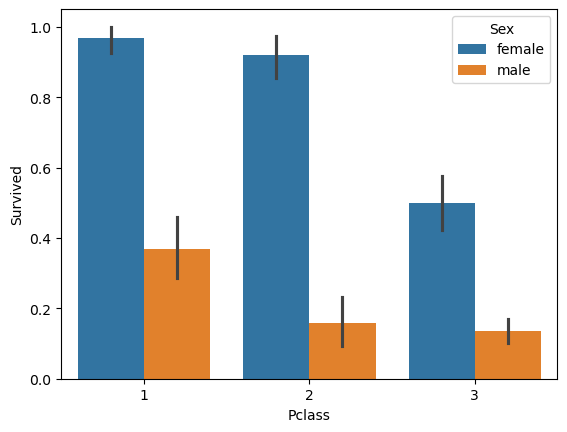

In [125]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)

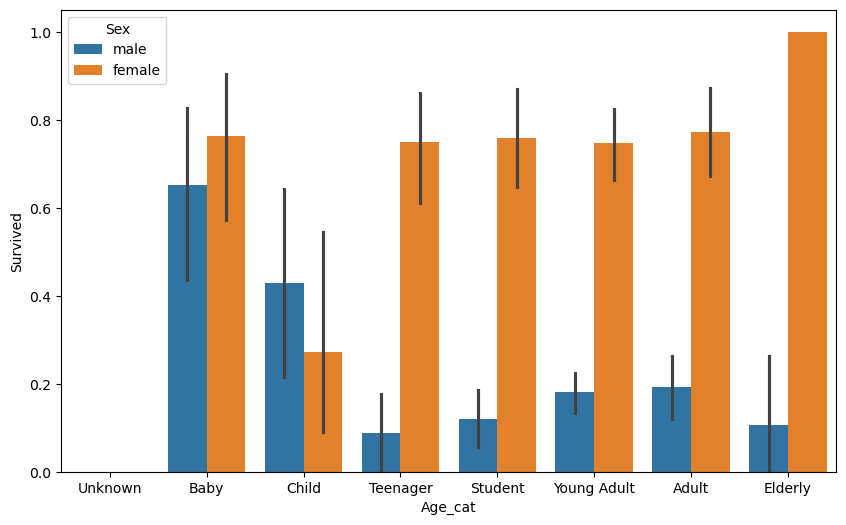

In [126]:
def get_category(age):
    cat=''
    if age<=-1: cat='Unknown'
    elif age<=5:cat='Baby'
    elif age<=12:cat='Child'
    elif age<=18:cat='Teenager'
    elif age<=25:cat='Student'
    elif age<=35:cat='Young Adult'
    elif age<=60:cat='Adult'
    else: cat='Elderly'
    return cat
plt.figure(figsize=(10,6))
group_names=['Unknown','Baby','Child','Teenager','Student','Young Adult','Adult','Elderly']
titanic_df['Age_cat']=titanic_df['Age'].apply(lambda x:get_category(x))
sns.barplot(x='Age_cat',y='Survived',hue='Sex',data=titanic_df,order=group_names)
titanic_df.drop('Age_cat',axis=1,inplace=True)

In [127]:
from sklearn.preprocessing import LabelEncoder
def encode_features(dataDf):
    features=['Cabin','Sex','Embarked']
    for feature in features:
        le=LabelEncoder()
        le.fit(dataDf[feature])
        dataDf[feature]=le.transform(dataDf[feature])
    return dataDf
titanic_df=encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [128]:
#NULL 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna('0',inplace=True)
    return df
#머신러닝 불요한 피처 제고
def drop_features(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df
#레이블 인코딩 수행
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features=['Cabin','Embarked','Sex']
    for feature in features:
        le=LabelEncoder()
        le.fit(df[feature])
        df[feature]=le.transform(df[feature])
    return df
#앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df=fillna(df)
    df=drop_features(df)
    df=format_features(df)
    return df
    

In [129]:
#원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df=pd.read_csv('train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
X_titanic_df=transform_features(X_titanic_df)

/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1328/976468700.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1328/976468700.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [130]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=11)

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dt_clf=DecisionTreeClassifier(random_state=11)
rf_clf=RandomForestClassifier(random_state=11)
lr_clf=LogisticRegression(solver='liblinear')

dt_clf.fit(X_train,y_train)
dt_pred=dt_clf.predict(X_test)
print('DecisionTreeClassifier의 정확도:{0:4f}'.format(accuracy_score(y_test,dt_pred)))

rf_clf.fit(X_train,y_train)
rf_pred=rf_clf.predict(X_test)
print('RandomForestClassifier의 정확도:{0:4f}'.format(accuracy_score(y_test,rf_pred)))

lr_clf.fit(X_train,y_train)
lr_pred=lr_clf.predict(X_test)
print('LogisticRegression의 정확도:{0:4f}'.format(accuracy_score(y_test,lr_pred)))



DecisionTreeClassifier의 정확도:0.787709
RandomForestClassifier의 정확도:0.854749
LogisticRegression의 정확도:0.865922


### 교차 검증을 해야만 최적의 알고리즘을 검증할 수 있다. 데이터의 양이 충분하지 않고 최적화 작업을 하지 않고

In [132]:
from sklearn.model_selection import KFold
def exec_kfold(clf,folds=5):
    kfold=KFold(n_splits=folds)
    scores=[]
    #KFold 교차 검증 수행
    for iter_count,(train_index,test_idex) in enumerate(kfold.split(X_titanic_df)):
        X_train,X_test=X_titanic_df.values[train_index],X_titanic_df.values[test_index]
        y_train,y_test=y_titanic_df.values[train_index],y_titanic_df.values[test_index]
        #classifier 학습, 예측 , 정확도 계산
        clf.fit(X_train,y_train)
        predictions=clf.predict(X_test)
        accuracy=accuracy_score(y_test,predictions)
        scores.append(accuracy)
        print('교차 검증 {0} 정확도: {1:4f}'.format(iter_count,accuracy))
    mean_score=np.mean(scores)
    print("평균 정확도: {0:4f}".format(mean_score))
#exec_kfold 호출
exec_kfold(dt_clf,folds=5)

교차 검증 0 정확도: 0.720000
교차 검증 1 정확도: 0.980000
교차 검증 2 정확도: 0.980000
교차 검증 3 정확도: 0.980000
교차 검증 4 정확도: 0.980000
평균 정확도: 0.928000


In [133]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(dt_clf,X_titanic_df,y_titanic_df,cv=5)
for iter_count, accuracy in enumerate(scores):
    print('교차 검증 {0} 정확도: {1:.4f}'.format(iter_count,accuracy))
print('평균 정확도: {0:.4f}'.format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


In [134]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(dt_clf,X_titanic_df,y_titanic_df,cv=5)
for iter_count,accuracy in enumerate(scores):
    print('교차 검증 {0} 정확도: {1:.4f}'.format(iter_count,accuracy))
print('평균 정확도: {0:.4f}'.format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


In [135]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[2,3,5,10],'min_samples_leaf':[1,5,8]}
grid_dclf=GridSearchCV(dt_clf,param_grid=parameters,scoring='accuracy',cv=5)
grid_dclf.fit(X_train,y_train)
print('GridSearchCV 최적 하이버 파라미터:',grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf=grid_dclf.best_estimator_
#최적의 파라미터로 학습된 estimator로 예측 및 평가 수행
dpredictions=best_dclf.predict(X_test)
accuracy=accuracy_score(y_test,dpredictions)
print('테스트 세트에서의 DeicisionTreeClassifier 정확도: {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이버 파라미터: {'max_depth': 3, 'min_samples_leaf': 5}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DeicisionTreeClassifier 정확도: 0.8715


# 군집화

## 1. K-평균 알고리즘 이해
#### ->K-평균 알고리즘은 군집화(clustering)에서 가장 많이 사용되는 알고리즘이다
#### ->군집 중심점(centroid)라는 특정의 임의의 지점 선택해 해당 중심에서 가장 가까운 포인트를 선택해 이동하는 방식

#### 장점: 제일 많이 사용되는 알고리즘 / 알고리즘 쉽고 간결하다
#### 단점: 거리 기반 알고리즘으로 속성의 개수가 많으면 군집화 정확도가 떨어져(PCA 차원 감소 필요), 반복 횟수가 많아지면 매우 느려짐, 몇 개의 군집 선택해야 할지 가이드하기 힘들다

### 1-2. 사이킷런 KMeans 클래스 소개

#### 가장 중요한 파라미터:n_clusters(군집화할 개수 & 중심점의 개수 의미)
#### init 초기의 군집 중심 좌표 설정 방식-일반적으로는 임의로 선정한다.
#### max_iter 최대 바복 횟수
#### labels_ 각 데이터 포인트가 속한 군집 중심점 레이블
#### cluster_centers_ 각 중심점 좌표->이후 시각화 가능

### 1-3. K-평균을 이용한 붖꽃 데이터 세트 군집화

In [136]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris=load_iris()
#더 편리하게 데이터 다루기 위해 DataFrame으로 변환
irisDf=pd.DataFrame(data=iris.data,columns=['sepal_length','sepal_width','petal_length','petal_width'])
irisDf.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [137]:
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0)
kmeans.fit(irisDf)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [138]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [139]:
irisDf['target']=iris.target
irisDf['cluster']=kmeans.labels_
iris_result=irisDf.groupby(['target','cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


#### 속성이 4개인데 2차원에 나타내고 싶으면 차원 축소를 해야한다.

In [140]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_transformed=pca.fit_transform(iris.data)
irisDf['pca_x']=pca_transformed[:,0]
irisDf['pca_y']=pca_transformed[:,1]
irisDf.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


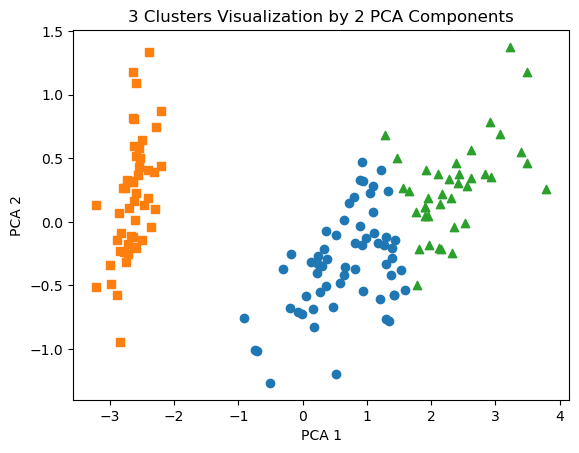

In [141]:
marker0_ind=irisDf[irisDf['cluster']==0].index
marker1_ind=irisDf[irisDf['cluster']==1].index
marker2_ind=irisDf[irisDf['cluster']==2].index

#군집 값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x,pca_y 값 추출 o,s,^로 마커 표시
plt.scatter(x=irisDf.loc[marker0_ind,'pca_x'],y=irisDf.loc[marker0_ind,'pca_y'],marker='o')
plt.scatter(x=irisDf.loc[marker1_ind,'pca_x'],y=irisDf.loc[marker1_ind,'pca_y'],marker='s')
plt.scatter(x=irisDf.loc[marker2_ind,'pca_x'],y=irisDf.loc[marker2_ind,'pca_y'],marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

## 군집화 알고리즘 테스트를 위한 데이터 생성

### make_blobs->대표적 군집화용 데이터 생성기
### 주요 파라미터
#### :n_samples:생성할 데이터 수 / n_features:데이터 피처 개수(시각화 목표시 2개) centers,cluster_std:생성될 데이터의 표준편차


In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline
X,y=make_blobs(n_samples=200,n_features=2,centers=3,cluster_std=0.8,random_state=0)
print(X.shape,y.shape)

#y target 값의 분포를 확인
unique,counts=np.unique(y,return_counts=True)
print(unique,counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [152]:
import pandas as pd
clusterDF=pd.DataFrame(data=X,columns=['ftr1','ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


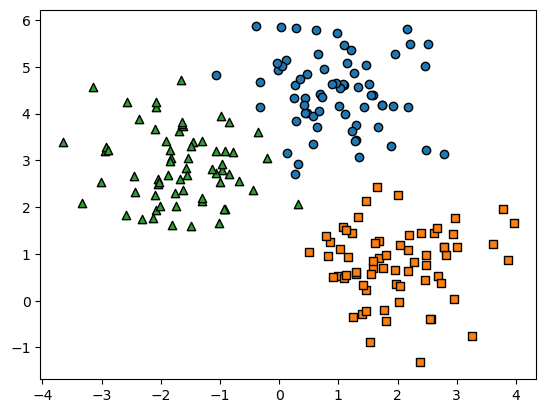

In [153]:
target_list=np.unique(y)
markers=['o','s','^','P','H','D','x']
for target in target_list:
    target_cluster=clusterDF[clusterDF['target']==target]
    plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],edgecolors='k',marker=markers[target])
plt.show()

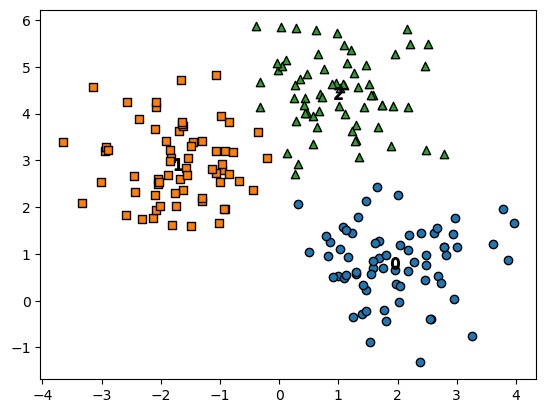

In [156]:
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=200,random_state=0)
cluster_labels=kmeans.fit_predict(X)
clusterDF['kmeans_label']=cluster_labels

centers=kmeans.cluster_centers_
unique_labels=np.unique(cluster_labels)
markers=['o','s','^','P','H','D','x']

#군집된 label 유형별로 iteration 하면서 marker 별 scatter plot 수행
for label in unique_labels:
    label_cluster=clusterDF[clusterDF['kmeans_label']==label]
    center_x_y_=centers[label]
    plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolor='k',marker=markers[label])
    #군집별 중심 위치 좌표 시각화
    plt.scatter(x=center_x_y_[0],y=center_x_y_[1],s=70,color='k',edgecolor='k',marker='$%d$'%label)
plt.show()

In [157]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


# 7-2 군집평가
### :분류와 비슷해 보일 수 있지만 성격이 다름 동일한, 데이터 내 별도 그룹에 새로운 의미를 부여하거나 동일한 분류 값에 속해도 더 세분화된 군집화가 가능하다

### 대표적 방법: 실루엣 분석

## 실루엣 분석의 개요
#### :각 군집 간의 거리가 얼마나 효율적으로 분리(다른 군집과의 거리는 떠져 있고 같은 거 끼리는 뭉쳐있는 것)되어 있는지 나타낸다
#### 실루엣 계수를 기반으로 분석을 하는데 이는 개별 데이터가 가지는 군집화 지표이다
#### 실루엣 계수-개별 데이터가 가지는 군집화 지표로 해당 데이터가 같은 군집내의 데이터와 얼마나 가깝게 군집되어 있고 다른 군집 데이터와 얼마나 멀리 분리되어 있는지 나타내는 지표

#### -> -1과 1사이 값을 가지면 1로 가까울 수로 근처의 군집과 떨어져 있다는 것이고 0에 가까울 수록 근처 군집과 가까워 짐 -값은 다른 군집에 데이터 포인트가 할당외었음을 의미

#### 좋은 군집화의 기준
#### 1.전체 실루엣 계수의 평균값이 0~1 사이이며 1에 가까울 수록 좋음
#### 2.실루엣 계수의 평균 값과 더불어 개별 군집의 평균 값의 편차가 크지 않아야 한다.

### 붖꽃 데이터 세트를 이용한 군집 평가

In [162]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris=load_iris()
feature_names=['sepal_length','sepal_width','petal_length','petal_width']
irisDF=pd.DataFrame(data=iris.data,columns=feature_names)
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(irisDF)
irisDF['cluster']=kmeans.labels_

#iris의 개별 데이터에 실루엣 계수 값을 구함
score_samples=silhouette_samples(iris.data,irisDF['cluster'])
print('silhouette_samples() return 값의 shape',score_samples.shape)

#irisDF에 실루엣 계수 칼럼 추가
irisDF['silhoutte_coeff']=score_samples

#모든 데이터의 평균 실루엣 계수 값을 구함
average_score=silhouette_score(iris.data,irisDF['cluster'])
print('붗꽃 데이터 세트 Silhouette Analysis Score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붗꽃 데이터 세트 Silhouette Analysis Score:0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhoutte_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [163]:
irisDF.groupby('cluster')['silhoutte_coeff'].mean()

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhoutte_coeff, dtype: float64

## 군집별 평균 실루엣 계수의 시각화를 통한  군집 개수 최적화 방법
#### :전체 데이터의 평균 실루엣 계수 값이 높다고 반드시 최적의 군집 개수로 군집화가 잘 되었다고 볼 수 없다. 예를 들어 특정한 군집 내만 너무 높고 나머지가 낮아도 평균적으로는 높을 수 있다.